### Predective Models

Comparar la capacidad predictiva de los tres datasets sobre los retornos o la volatilidad futura

1. Modelos estadísticos (interpretable baseline): 
- ARIMA / AR -> predicen el valor de los retornos.
- GARCH / EGARCH -> predicen la volatilidad condicional (riesgo) 


2. Modelos ML (capturan no linealidades)
- Random Forest Regressor 
- XGBoost
- LSTM 0 GRU

In [40]:
# imports 
# imports 
from statsmodels.stats.diagnostic import het_arch 
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import datetime as dt
# timestamp 
import time

In [41]:
# data
# load data from csv 
original_data = pd.read_csv('../data/processed/BTCUSDT_1m_2024-12-01_to_2025-01-01_cleaned_robust.csv')
volume_data = pd.read_csv('../data/processed/BTCUSDT_1m_2024-12-01_to_2025-01-volume.csv')
dolar_data = pd.read_csv('../data/processed/BTCUSDT_1m_2024-12-01_to_2025-01-01_dollar_bars_dyn.csv')


In [42]:
datasets = {
    'original_data': original_data,
    'volume_data': volume_data,
    'dolar_data': dolar_data
}


In [43]:
def add_features(df : pd.DataFrame):
    df = df.copy()
    df['returns'] = df['close'].pct_change().dropna()
    df['returns_lag1'] = df['returns'].shift(1)
    df['returns_lag2'] = df['returns'].shift(2)
    df['volatility'] = df['returns'].rolling(10).std()

    df = df.dropna().reset_index(drop=True)

    return pd.DataFrame(df)

def set_dataset_features():
    processed = {}
    for name, df in datasets.items():
        processed[name] = add_features(df)

    return processed

processed_datasets = set_dataset_features()


#### AutoReg (AR)

Predice los retornos en función de los rezagos

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np

def clean_dataframe(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['return'])
    df = df.reset_index(drop=True)
    return df

for name, df in datasets.items():
    try:
        df = clean_dataframe(df)

        # Entrenar modelo con lags=5
        model = AutoReg(df['return'], lags=5, old_names=False).fit()

        # Asegurarse de no pasar más datos de los que existen
        start = len(df) - 100 if len(df) > 100 else 5
        end = len(df) - 1

        predictions = model.predict(start=start, end=end)

        # Alinear longitudes antes del cálculo del MSE
        y_true = df['return'].iloc[start:end+1]
        mse = mean_squared_error(y_true, predictions)

        print(f"{name} - MSE: {mse}")
    except Exception as e:
        print(f"Error con {name}:", e)


original_data - MSE: 6.042281255599768e-08
volume_data - MSE: 5.764152246957042e-06
dolar_data - MSE: 5.646970500674678e-07



Entrenando GARCH(1,1) en original_data...


/home/llamqak/.local/share/mamba/envs/ML/lib/python3.13/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.247e-07. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/home/llamqak/.local/share/mamba/envs/ML/lib/python3.13/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


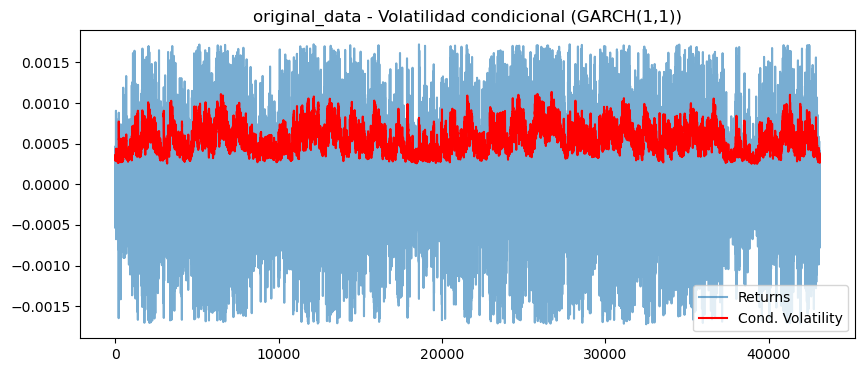


Entrenando GARCH(1,1) en volume_data...


/home/llamqak/.local/share/mamba/envs/ML/lib/python3.13/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.386e-06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


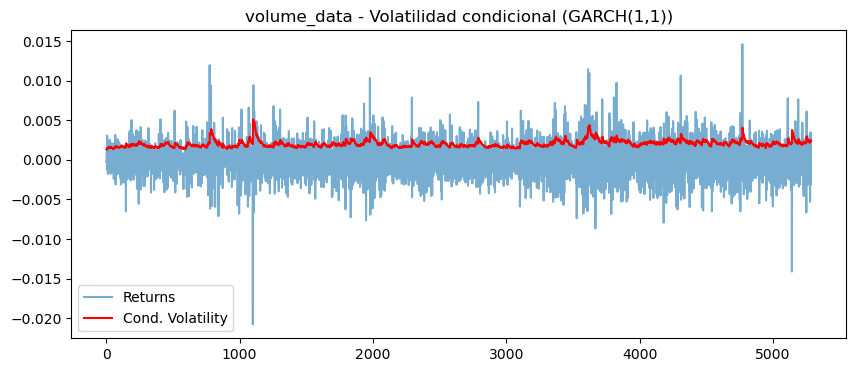


Entrenando GARCH(1,1) en dolar_data...


/home/llamqak/.local/share/mamba/envs/ML/lib/python3.13/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.78e-07. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/home/llamqak/.local/share/mamba/envs/ML/lib/python3.13/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


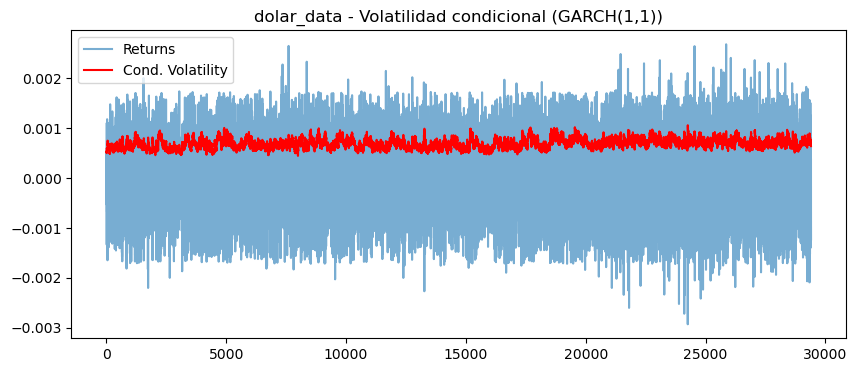


📊 Resultados comparativos:
                      omega  alpha  beta  persistence       MSE_var
original_data  6.494121e-09   0.10  0.88         0.98  2.323766e-13
volume_data    8.772547e-08   0.05  0.93         0.98  1.115200e-10
dolar_data     9.559857e-09   0.05  0.93         0.98  4.105567e-13


In [49]:
from arch import arch_model
import matplotlib.pyplot as plt
import pandas as pd

# Diccionario con tus datasets
datasets = {
    'original_data': original_data,
    'volume_data': volume_data,
    'dolar_data': dolar_data
}

results = {}

for name, df in datasets.items():
    print(f"\nEntrenando GARCH(1,1) en {name}...")
    
    # Asegurar que haya columna 'return' y sin NaN
    if 'return' not in df.columns:
        print(f"⚠️ {name} no tiene columna 'return'. Saltando...")
        continue
    returns = df['return'].dropna()
    
    if returns.empty:
        print(f"⚠️ {name} no tiene datos válidos. Saltando...")
        continue
    
    # Definir modelo GARCH(1,1)
    model = arch_model(returns, vol='GARCH', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    
    # Guardar resultados clave
    alpha = res.params.get('alpha[1]', float('nan'))
    beta = res.params.get('beta[1]', float('nan'))
    omega = res.params.get('omega', float('nan'))
    persistence = alpha + beta
    
    # Calcular error de la varianza condicional vs retornos²
    pred_var = res.conditional_volatility**2
    mse = ((returns**2 - pred_var)**2).mean()
    
    results[name] = {
        'omega': omega,
        'alpha': alpha,
        'beta': beta,
        'persistence': persistence,
        'MSE_var': mse
    }

    # Graficar volatilidad condicional
    plt.figure(figsize=(10,4))
    plt.plot(returns.index, returns, label='Returns', alpha=0.6)
    plt.plot(returns.index, res.conditional_volatility, label='Cond. Volatility', color='red')
    plt.title(f'{name} - Volatilidad condicional (GARCH(1,1))')
    plt.legend()
    plt.show()

# Mostrar resumen comparativo
summary = pd.DataFrame(results).T
print("\n📊 Resultados comparativos:")
print(summary)